In [ ]:
import numpy as np
import struct

# -------------------------
# Function to load MNIST images
# -------------------------
def load_mnist_images(filename, max_samples=None):
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))

        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)

        # Normalize pixel values to [0,1]
        images = images.astype(np.float32) / 255.0

        if max_samples:
            images = images[:max_samples]

        print(f"Loaded {images.shape[0]} images of size {rows}x{cols}")
        return images


# -------------------------
# Function to load MNIST labels
# -------------------------
def load_mnist_labels(filename, max_samples=None):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))

        labels = np.frombuffer(f.read(), dtype=np.uint8)

        if max_samples:
            labels = labels[:max_samples]

        print(f"Loaded {labels.shape[0]} labels")
        return labels


# -------------------------
# Preprocessing function
# -------------------------
def preprocess_images(images):
    # Flatten 28x28 → 784
    num_samples = images.shape[0]
    images_flat = images.reshape(num_samples, -1)

    print(f"Images reshaped to: {images_flat.shape}")
    return images_flat

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
import numpy as np
import struct
import zipfile
import os

# -------------------------
# Step 0: Extract dataset
# -------------------------
with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall('mnist_data')

print("Files inside dataset:", os.listdir('mnist_data'))


# -------------------------
# Function to load MNIST images
# -------------------------
def load_mnist_images(filename, max_samples=None):
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))

        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)

        # Normalize to [0,1]
        images = images.astype(np.float32) / 255.0

        if max_samples:
            images = images[:max_samples]

        print(f"Loaded {images.shape[0]} images of size {rows}x{cols}")
        return images


# -------------------------
# Function to load MNIST labels
# -------------------------
def load_mnist_labels(filename, max_samples=None):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))

        labels = np.frombuffer(f.read(), dtype=np.uint8)

        if max_samples:
            labels = labels[:max_samples]

        print(f"Loaded {labels.shape[0]} labels")
        return labels


# -------------------------
# Preprocessing function
# -------------------------
def preprocess_images(images):
    num_samples = images.shape[0]
    images_flat = images.reshape(num_samples, -1)

    print(f"Images reshaped to: {images_flat.shape}")
    return images_flat


# -------------------------
# Load dataset (FIXED PATHS)
# -------------------------
train_images = load_mnist_images('mnist_data/train-images.idx3-ubyte', max_samples=5000)
train_labels = load_mnist_labels('mnist_data/train-labels.idx1-ubyte', max_samples=5000)

test_images = load_mnist_images('mnist_data/t10k-images.idx3-ubyte', max_samples=1000)
test_labels = load_mnist_labels('mnist_data/t10k-labels.idx1-ubyte', max_samples=1000)


# -------------------------
# Dataset info (Objective 1)
# -------------------------
print("\n--- Dataset Information ---")
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

print("\nUnique classes:", np.unique(train_labels))
print("Number of classes:", len(np.unique(train_labels)))


# -------------------------
# Preprocessing (Objective 2)
# -------------------------
X_train = preprocess_images(train_images)
X_test = preprocess_images(test_images)

y_train = train_labels
y_test = test_labels

print("\nAfter preprocessing:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Files inside dataset: ['train-images-idx3-ubyte', 't10k-images-idx3-ubyte', 'train-labels-idx1-ubyte', 't10k-labels-idx1-ubyte', 'train-labels.idx1-ubyte', 't10k-images.idx3-ubyte', 'train-images.idx3-ubyte', 't10k-labels.idx1-ubyte']
Loaded 5000 images of size 28x28
Loaded 5000 labels
Loaded 1000 images of size 28x28
Loaded 1000 labels

--- Dataset Information ---
Train images shape: (5000, 28, 28)
Train labels shape: (5000,)
Test images shape: (1000, 28, 28)
Test labels shape: (1000,)

Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10
Images reshaped to: (5000, 784)
Images reshaped to: (1000, 784)

After preprocessing:
X_train shape: (5000, 784)
X_test shape: (1000, 784)


In [ ]:
# -------------------------
# Load small subset (FIXED PATHS)
# -------------------------
train_images = load_mnist_images('mnist_data/train-images.idx3-ubyte', max_samples=5000)
train_labels = load_mnist_labels('mnist_data/train-labels.idx1-ubyte', max_samples=5000)

test_images = load_mnist_images('mnist_data/t10k-images.idx3-ubyte', max_samples=1000)
test_labels = load_mnist_labels('mnist_data/t10k-labels.idx1-ubyte', max_samples=1000)


# -------------------------
# Dataset info (Objective 1)
# -------------------------
print("\n--- Dataset Information ---")
print("Train images:", train_images.shape)
print("Train labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

# Extra (important for marks)
print("\nUnique classes:", np.unique(train_labels))

Loaded 5000 images of size 28x28
Loaded 5000 labels
Loaded 1000 images of size 28x28
Loaded 1000 labels

--- Dataset Information ---
Train images: (5000, 28, 28)
Train labels: (5000,)
Test images: (1000, 28, 28)
Test labels: (1000,)

Unique classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def dataset_statistics(images, labels, dataset_name="Train"):
    print(f"\n=== {dataset_name} Dataset ===")
    print("Number of samples:", len(labels))
    print("Image shape:", images.shape[1:])
    print("Unique labels:", np.unique(labels))

    # Count samples per class
    class_counts = np.bincount(labels)
    for i, count in enumerate(class_counts):
        print(f"Class {i}: {count} samples")

    # -------------------------
    # Plot class distribution
    # -------------------------
    plt.figure(figsize=(8,4))
    sns.barplot(x=np.arange(len(class_counts)), y=class_counts)
    plt.title(f"{dataset_name} Set - Samples per Class")
    plt.xlabel("Digit Class")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    # -------------------------
    # Show sample images
    # -------------------------
    plt.figure(figsize=(12,3))
    for i in range(10):
        indices = np.where(labels == i)[0]

        if len(indices) > 0:   # 🔥 FIX (avoid crash if class missing)
            idx = indices[0]
            plt.subplot(1, 10, i+1)
            plt.imshow(images[idx], cmap='gray')
            plt.axis('off')
            plt.title(f"{i}")

    plt.suptitle(f"Example images from {dataset_name} set")
    plt.show()


# -------------------------
# Run diagnostics
# -------------------------
dataset_statistics(train_images, train_labels, "Train")
dataset_statistics(test_images, test_labels, "Test")

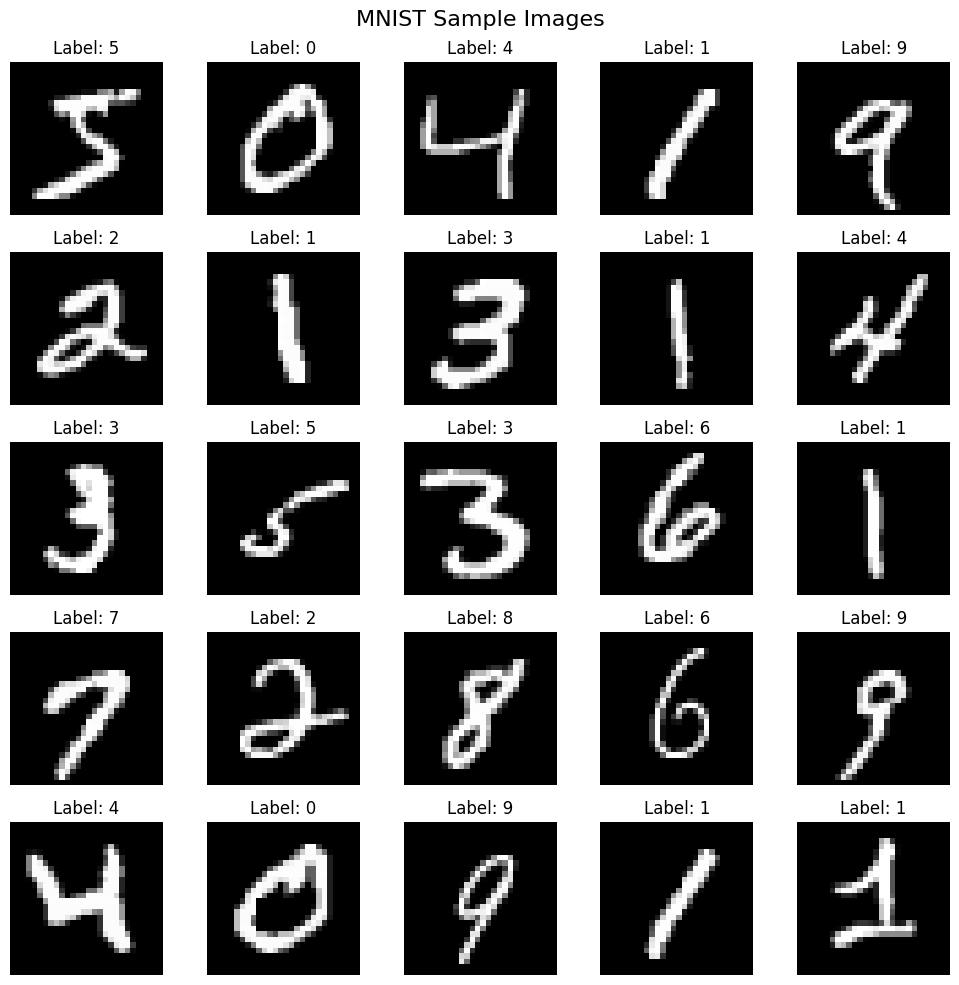

In [ ]:
import matplotlib.pyplot as plt

# -------------------------
# Function to plot grid
# -------------------------
def plot_mnist_grid(images, labels, grid_size=5):
    """
    Plots a grid of MNIST images with labels.
    """
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flatten()

    total_images = min(len(images), grid_size * grid_size)  # 🔥 safety

    for i in range(total_images):
        axes[i].imshow(images[i], cmap='gray')
        axes[i].set_title(f"Label: {labels[i]}")
        axes[i].axis('off')

    # Hide extra empty plots (if any)
    for i in range(total_images, grid_size * grid_size):
        axes[i].axis('off')

    plt.suptitle("MNIST Sample Images", fontsize=16)
    plt.tight_layout()
    plt.show()


# -------------------------
# Example usage
# -------------------------
plot_mnist_grid(train_images, train_labels)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, model_name="Model"):
    print(f"\n=== {model_name} Evaluation ===")

    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return acc

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# -------------------------
# Train KNN model
# -------------------------
knn = KNeighborsClassifier(n_neighbors=3)  # k = 3
knn.fit(X_train, y_train)

# -------------------------
# Predictions
# -------------------------
y_pred_knn = knn.predict(X_test)

# -------------------------
# Evaluation
# -------------------------
knn_acc = evaluate_model(y_test, y_pred_knn, "KNN")



=== KNN Evaluation ===
Accuracy: 0.909

Confusion Matrix:
[[ 84   0   0   0   0   0   1   0   0   0]
 [  0 126   0   0   0   0   0   0   0   0]
 [  2   4  99   0   1   0   2   6   2   0]
 [  0   3   1  94   0   2   1   2   2   2]
 [  0   2   0   0  99   0   1   0   0   8]
 [  0   1   0   2   1  78   2   0   2   1]
 [  2   0   0   0   1   0  84   0   0   0]
 [  0   6   1   0   1   1   0  89   0   1]
 [  4   1   2   3   2   3   1   0  70   3]
 [  0   0   0   0   5   0   0   2   1  86]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95        85
           1       0.88      1.00      0.94       126
           2       0.96      0.85      0.90       116
           3       0.95      0.88      0.91       107
           4       0.90      0.90      0.90       110
           5       0.93      0.90      0.91        87
           6       0.91      0.97      0.94        87
           7       0.90      0.90      0.90        99

In [ ]:
from sklearn.linear_model import LogisticRegression

# -------------------------
# Train Logistic Regression
# -------------------------
log_reg = LogisticRegression(max_iter=1000)  # increase iterations for convergence
log_reg.fit(X_train, y_train)

# -------------------------
# Predictions
# -------------------------
y_pred_lr = log_reg.predict(X_test)

# -------------------------
# Evaluation
# -------------------------
lr_acc = evaluate_model(y_test, y_pred_lr, "Logistic Regression")


=== Logistic Regression Evaluation ===
Accuracy: 0.883

Confusion Matrix:
[[ 81   0   1   1   0   1   1   0   0   0]
 [  0 125   0   0   0   0   1   0   0   0]
 [  0   2  96   2   0   1   1   5   6   3]
 [  1   0   3  88   0   9   1   3   2   0]
 [  1   1   1   0  99   0   1   0   2   5]
 [  1   0   0   3   2  71   1   1   6   2]
 [  3   0   2   0   1   2  78   1   0   0]
 [  0   2   5   1   1   0   0  86   0   4]
 [  0   0   0   4   2   3   1   3  75   1]
 [  0   0   0   1   3   1   0   5   0  84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        85
           1       0.96      0.99      0.98       126
           2       0.89      0.83      0.86       116
           3       0.88      0.82      0.85       107
           4       0.92      0.90      0.91       110
           5       0.81      0.82      0.81        87
           6       0.92      0.90      0.91        87
           7       0.83      0.87    

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# -------------------------
# Train Decision Tree
# -------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# -------------------------
# Predictions
# -------------------------
y_pred_dt = dt.predict(X_test)

# -------------------------
# Evaluation
# -------------------------
dt_acc = evaluate_model(y_test, y_pred_dt, "Decision Tree")


=== Decision Tree Evaluation ===
Accuracy: 0.752

Confusion Matrix:
[[ 74   0   2   1   1   1   0   2   4   0]
 [  0 121   0   1   1   0   0   1   1   1]
 [  3   6  74   8   5   1   5   5   4   5]
 [  3   4   2  71   2   7   1   5   6   6]
 [  1   0   2   0  91   5   2   1   3   5]
 [  1   1   0   7   5  57   5   3   6   2]
 [  5   1   2   1   0   1  70   1   2   4]
 [  0   2   4   4   1   0   1  76   2   9]
 [  2   5   6   8   4   8   2   1  48   5]
 [  1   0   3   2   4   6   1   3   4  70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85        85
           1       0.86      0.96      0.91       126
           2       0.78      0.64      0.70       116
           3       0.69      0.66      0.68       107
           4       0.80      0.83      0.81       110
           5       0.66      0.66      0.66        87
           6       0.80      0.80      0.80        87
           7       0.78      0.77      0.77

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# -------------------------
# Train Random Forest
# -------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# -------------------------
# Predictions
# -------------------------
y_pred_rf = rf.predict(X_test)

# -------------------------
# Evaluation
# -------------------------
rf_acc = evaluate_model(y_test, y_pred_rf, "Random Forest")


=== Random Forest Evaluation ===
Accuracy: 0.931

Confusion Matrix:
[[ 84   0   0   0   0   0   1   0   0   0]
 [  0 125   0   1   0   0   0   0   0   0]
 [  0   0 104   3   1   0   1   3   4   0]
 [  0   0   0  93   0   8   1   3   0   2]
 [  0   0   2   0 102   0   0   1   0   5]
 [  1   0   0   0   1  82   0   0   1   2]
 [  2   0   0   0   1   1  83   0   0   0]
 [  0   0   3   0   1   0   0  92   0   3]
 [  0   0   3   2   2   0   1   1  78   2]
 [  0   1   0   1   1   0   0   0   3  88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        85
           1       0.99      0.99      0.99       126
           2       0.93      0.90      0.91       116
           3       0.93      0.87      0.90       107
           4       0.94      0.93      0.93       110
           5       0.90      0.94      0.92        87
           6       0.95      0.95      0.95        87
           7       0.92      0.93      0.92

In [ ]:
from sklearn.svm import SVC

# -------------------------
# Train SVM
# -------------------------
svm = SVC(kernel='linear')   # linear kernel (faster)
svm.fit(X_train, y_train)

# -------------------------
# Predictions
# -------------------------
y_pred_svm = svm.predict(X_test)

# -------------------------
# Evaluation
# -------------------------
svm_acc = evaluate_model(y_test, y_pred_svm, "SVM")


=== SVM Evaluation ===
Accuracy: 0.887

Confusion Matrix:
[[ 82   0   0   0   0   1   2   0   0   0]
 [  0 125   0   0   0   0   1   0   0   0]
 [  1   3  99   2   2   1   1   3   4   0]
 [  0   1   1  95   0   6   1   1   1   1]
 [  0   1   1   0 103   0   0   0   0   5]
 [  1   0   0   4   0  75   1   0   4   2]
 [  2   0   1   0   2   1  80   0   1   0]
 [  1   1   7   1   2   1   0  81   1   4]
 [  1   0   2   7   2   3   0   4  69   1]
 [  0   1   0   1   7   1   0   6   0  78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        85
           1       0.95      0.99      0.97       126
           2       0.89      0.85      0.87       116
           3       0.86      0.89      0.88       107
           4       0.87      0.94      0.90       110
           5       0.84      0.86      0.85        87
           6       0.93      0.92      0.92        87
           7       0.85      0.82      0.84        99

In [ ]:
import pandas as pd

# Store results
results = {
    "Model": ["KNN", "Logistic Regression", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [knn_acc, lr_acc, dt_acc, rf_acc, svm_acc]
}

df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(df)


=== Model Comparison ===
                 Model  Accuracy
0                  KNN     0.909
1  Logistic Regression     0.883
2        Decision Tree     0.752
3        Random Forest     0.931
4                  SVM     0.887
